In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import joblib




In [2]:
print("Loading data...")
df = pd.read_csv('C:\\Users\\srima\\ml\\data_set.csv')




Loading data...


In [3]:
print("Compressing features...")
features = df.columns.drop(['CONS_NO', 'FLAG'])
df['avg_current'] = df[features].mean(axis=1)
df['zero_days'] = (df[features] == 0).sum(axis=1)
row_medians = df[features].median(axis=1)
for col in features:
    df[col] = df[col].replace(0, np.nan).fillna(row_medians)
df[features] = df[features].fillna(0)




Compressing features...


In [4]:
def assign_size(row):
    if row['FLAG'] == 1:
        return np.random.randint(4, 6) 
    else:
        if row['avg_current'] > 10: return np.random.randint(4, 6) 
        elif row['avg_current'] > 5: return np.random.randint(2, 4) 
        else: return 1 
df['avg_current'] = df[features].mean(axis=1)
df['zero_days'] = (df[features] == 0).sum(axis=1)
df['house_size'] = df.apply(assign_size, axis=1)

data=df.drop('CONS_NO', axis=1)



C:\Users\srima\AppData\Local\Temp\ipykernel_3008\2505221149.py:10: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['house_size'] = df.apply(assign_size, axis=1)


In [5]:

X = df[['avg_current', 'house_size', 'zero_days']]
y = df['FLAG']




In [6]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)



In [7]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)




In [8]:
custom_weights = {0: 1, 1: 7}
model = RandomForestClassifier(n_estimators=100, class_weight=custom_weights, random_state=42)
model.fit(X_train_scaled, y_train)




,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [9]:
y_pred = model.predict(X_test_scaled)
print("\n--- MODEL PERFORMANCE ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.2f}")
print(classification_report(y_test, y_pred))
cm = confusion_matrix(y_test, y_pred)



--- MODEL PERFORMANCE ---
Accuracy: 0.94
              precision    recall  f1-score   support

           0       0.96      0.97      0.97      7752
           1       0.65      0.62      0.63       723

    accuracy                           0.94      8475
   macro avg       0.81      0.79      0.80      8475
weighted avg       0.94      0.94      0.94      8475



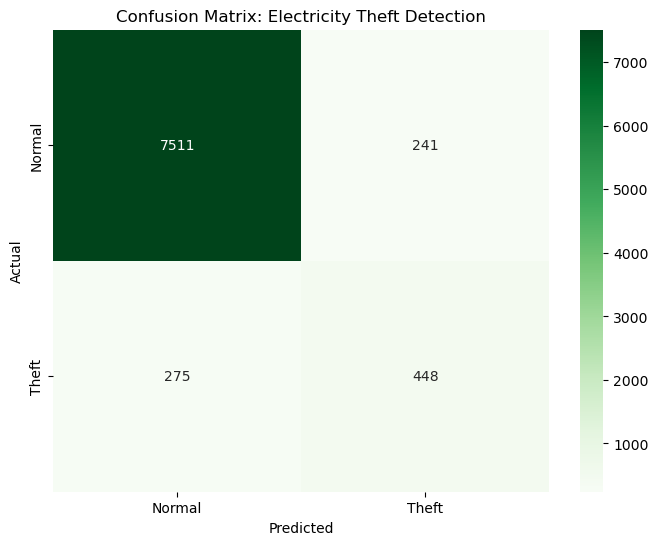

In [10]:
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', 
            xticklabels=['Normal', 'Theft'], 
            yticklabels=['Normal', 'Theft'])
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title('Confusion Matrix: Electricity Theft Detection')
plt.show()




In [11]:
joblib.dump(model, 'theft_model.pkl')
joblib.dump(scaler, 'scaler.pkl')
print("\nSuccess! 'theft_model.pkl' and 'scaler.pkl' are ready for FastAPI.")



Success! 'theft_model.pkl' and 'scaler.pkl' are ready for FastAPI.
